In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import os

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

os.makedirs("visualizations", exist_ok=True)

df = pd.read_csv("sales_data.csv")
df.columns = df.columns.str.strip()

print("Columns in dataset:", df.columns)

col_category = df.columns[2]
col_region = df.columns[3]
col_sales = df.columns[-1]
col_date = df.columns[1]

df[col_date] = pd.to_datetime(df[col_date], errors='coerce')

df.head()

Columns in dataset: Index(['Date', 'Product', 'Quantity', 'Price', 'Customer_ID', 'Region',
       'Total_Sales'],
      dtype='object')


/var/folders/d4/lt43_1297n37fjzw_z8tnr8r0000gn/T/ipykernel_2743/3052296534.py:22: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,NaT,7,37300,CUST001,East,261100
1,2024-01-02,NaT,4,15406,CUST002,North,61624
2,2024-01-03,NaT,2,21746,CUST003,West,43492
3,2024-01-04,NaT,1,30895,CUST004,East,30895
4,2024-01-05,NaT,8,39835,CUST005,North,318680


Box Plot: Sales Distribution by Category


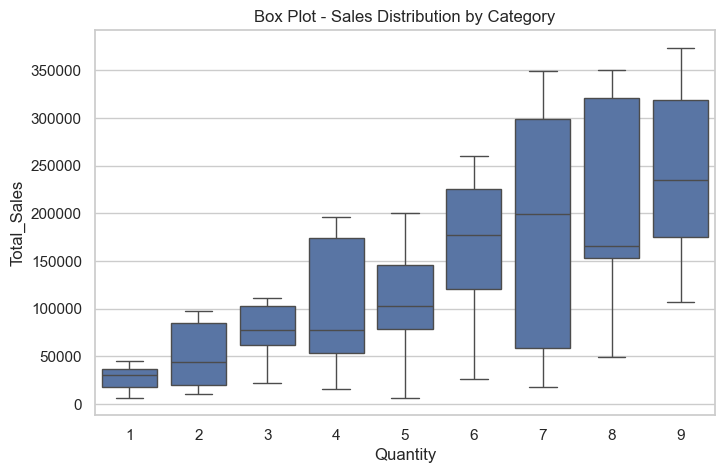

In [30]:
print("Box Plot: Sales Distribution by Category")

plt.figure()
sns.boxplot(x=col_category, y=col_sales, data=df)
plt.title("Box Plot - Sales Distribution by Category")

plt.savefig("visualizations/boxplot.png")
plt.show()

 Violin Plot: Sales Distribution by Region


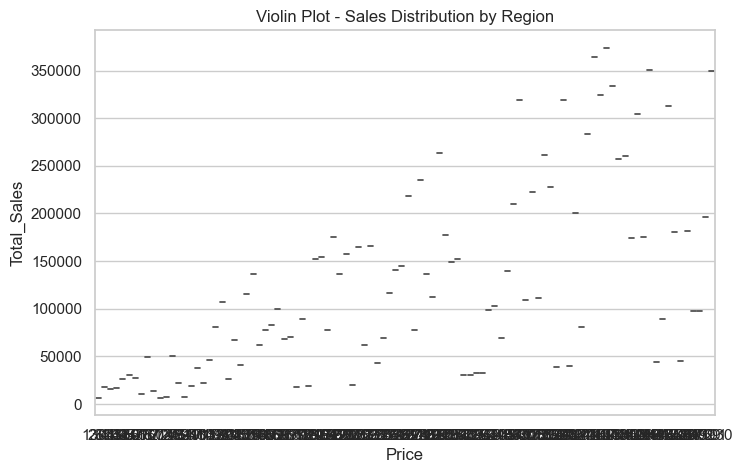

In [29]:
print(" Violin Plot: Sales Distribution by Region")

plt.figure()
sns.violinplot(x=col_region, y=col_sales, data=df)
plt.title("Violin Plot - Sales Distribution by Region")

plt.savefig("visualizations/violinplot.png")
plt.show()

 Heatmap: Correlation Matrix


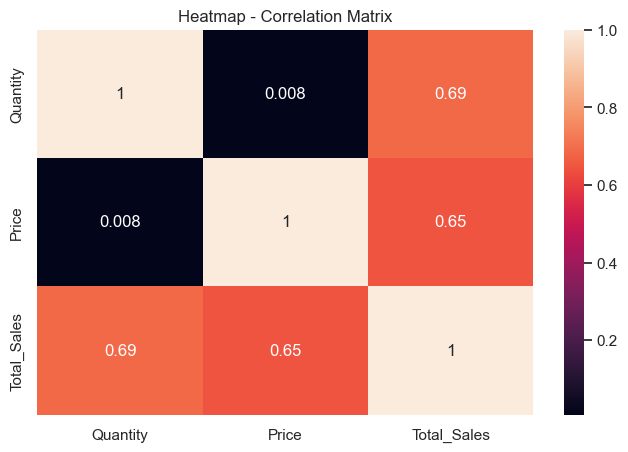

In [28]:
print(" Heatmap: Correlation Matrix")

plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Heatmap - Correlation Matrix")

plt.savefig("visualizations/heatmap.png")
plt.show()

Line Plot: Sales Trend Over Time


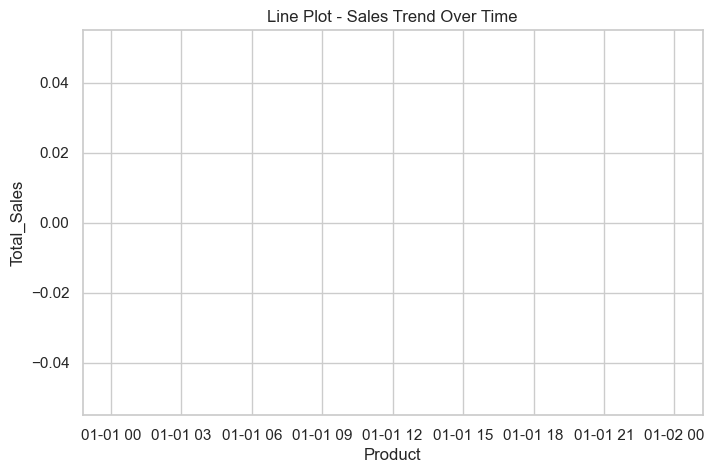

In [27]:
print("Line Plot: Sales Trend Over Time")

plt.figure()
sns.lineplot(x=col_date, y=col_sales, data=df)
plt.title("Line Plot - Sales Trend Over Time")

plt.savefig("visualizations/lineplot.png")
plt.show()

 Bar Plot: Average Sales by Category


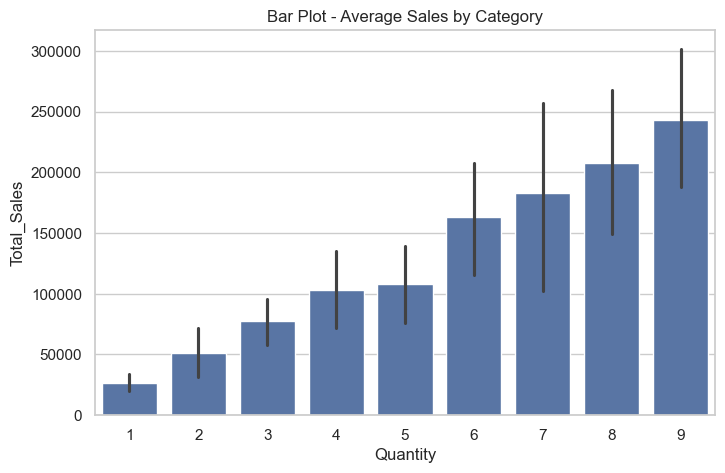

In [26]:
print(" Bar Plot: Average Sales by Category")

plt.figure()
sns.barplot(x=col_category, y=col_sales, data=df)
plt.title("Bar Plot - Average Sales by Category")

plt.savefig("visualizations/barplot.png")
plt.show()

Dashboard View (Multiple Plots)


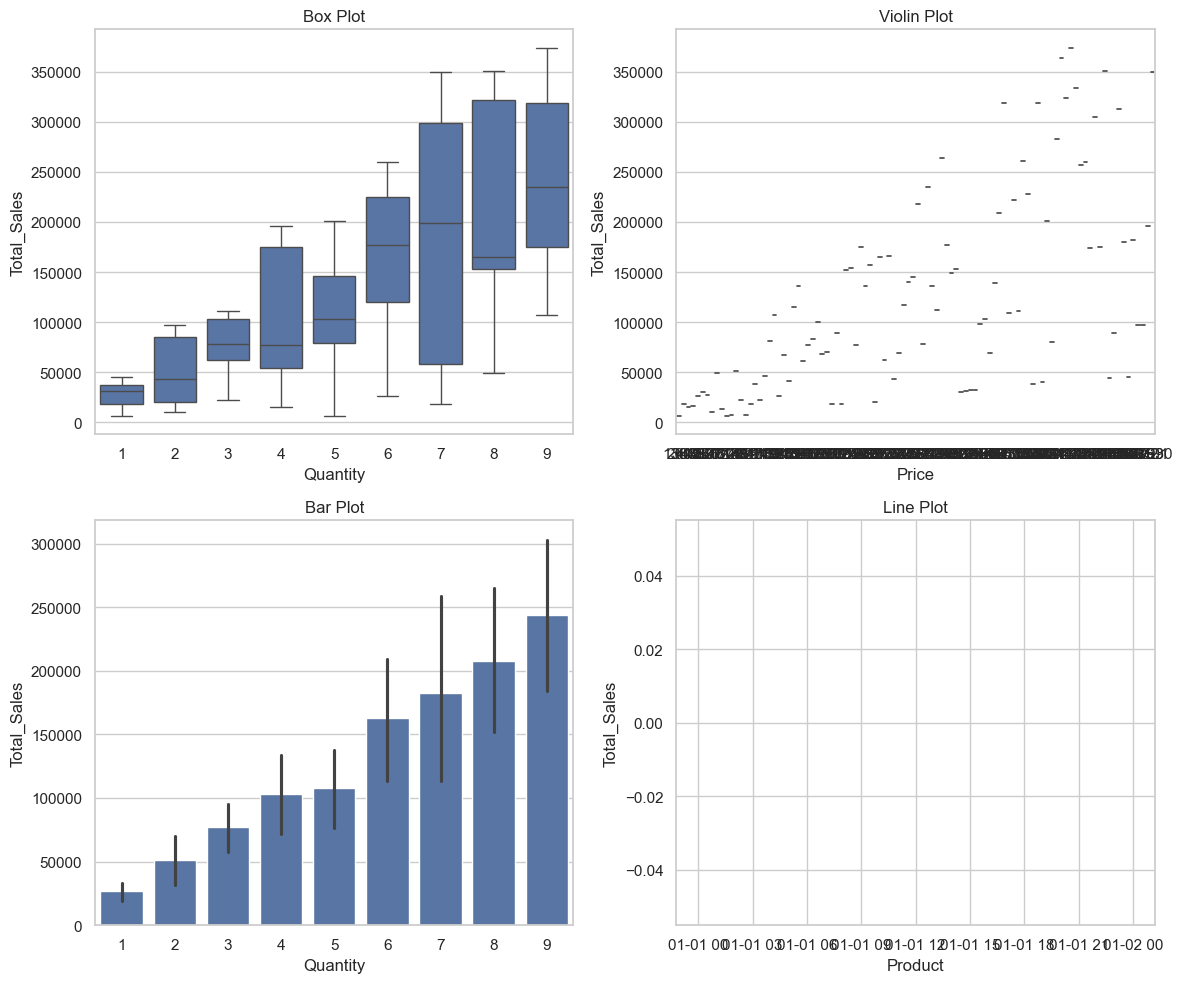

In [31]:
print("Dashboard View (Multiple Plots)")

fig, axes = plt.subplots(2, 2, figsize=(12,10))

sns.boxplot(x=col_category, y=col_sales, data=df, ax=axes[0,0])
axes[0,0].set_title("Box Plot")

sns.violinplot(x=col_region, y=col_sales, data=df, ax=axes[0,1])
axes[0,1].set_title("Violin Plot")

sns.barplot(x=col_category, y=col_sales, data=df, ax=axes[1,0])
axes[1,0].set_title("Bar Plot")

sns.lineplot(x=col_date, y=col_sales, data=df, ax=axes[1,1])
axes[1,1].set_title("Line Plot")

plt.tight_layout()
plt.savefig("visualizations/dashboard.png")
plt.show()

Interactive Line Chart (Hover Enabled)


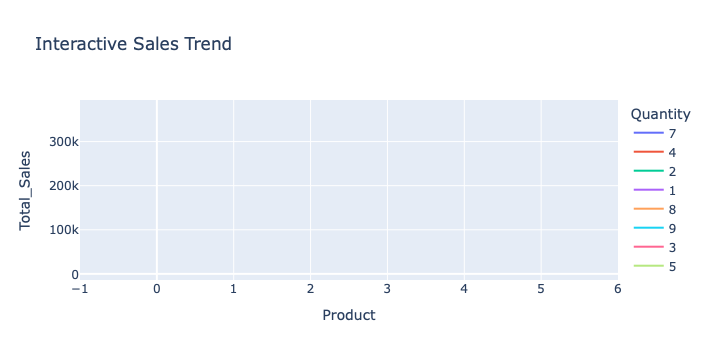

In [32]:
print("Interactive Line Chart (Hover Enabled)")

fig = px.line(df, x=col_date, y=col_sales, color=col_category,
              title="Interactive Sales Trend")

fig.show()
fig.write_html("visualizations/interactive_line.html")

Interactive Bar Chart


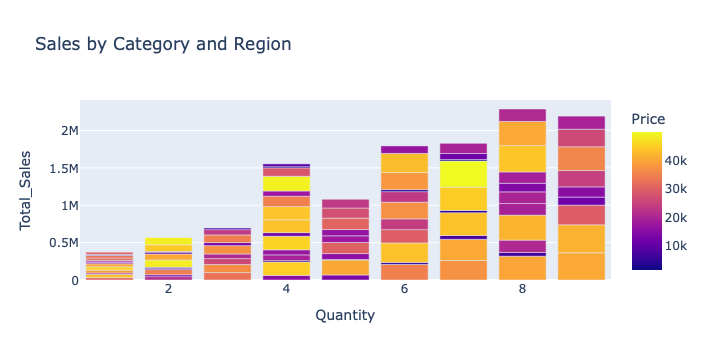

In [33]:
print("Interactive Bar Chart")

fig = px.bar(df, x=col_category, y=col_sales, color=col_region,
             title="Sales by Category and Region", barmode='group')

fig.show()
fig.write_html("visualizations/interactive_bar.html")